In [6]:
### import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
import xgboost as xgb
from xgboost import XGBClassifier
import random
import os
np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"
import math
from sklearn.utils.class_weight import compute_sample_weight

In [7]:
## Load dataset
import os
if os.path.exists("CEP_Train_Data.csv"):
    df = pd.read_csv("CEP_Train_Data.csv")
else:
    df = pd.read_csv("/content/CEP_Train_Data.csv")

In [8]:
### initial inspection
df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [9]:
df.shape

(1000000, 20)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [11]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


In [12]:
### missing values and duplicates
df.isnull().sum()

,0
age,0
gender,0
academic_year,0
study_hours_per_day,0
exam_pressure,0
academic_performance,0
stress_level,0
anxiety_score,0
depression_score,0
sleep_hours,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
### seperate column types
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include="number").columns

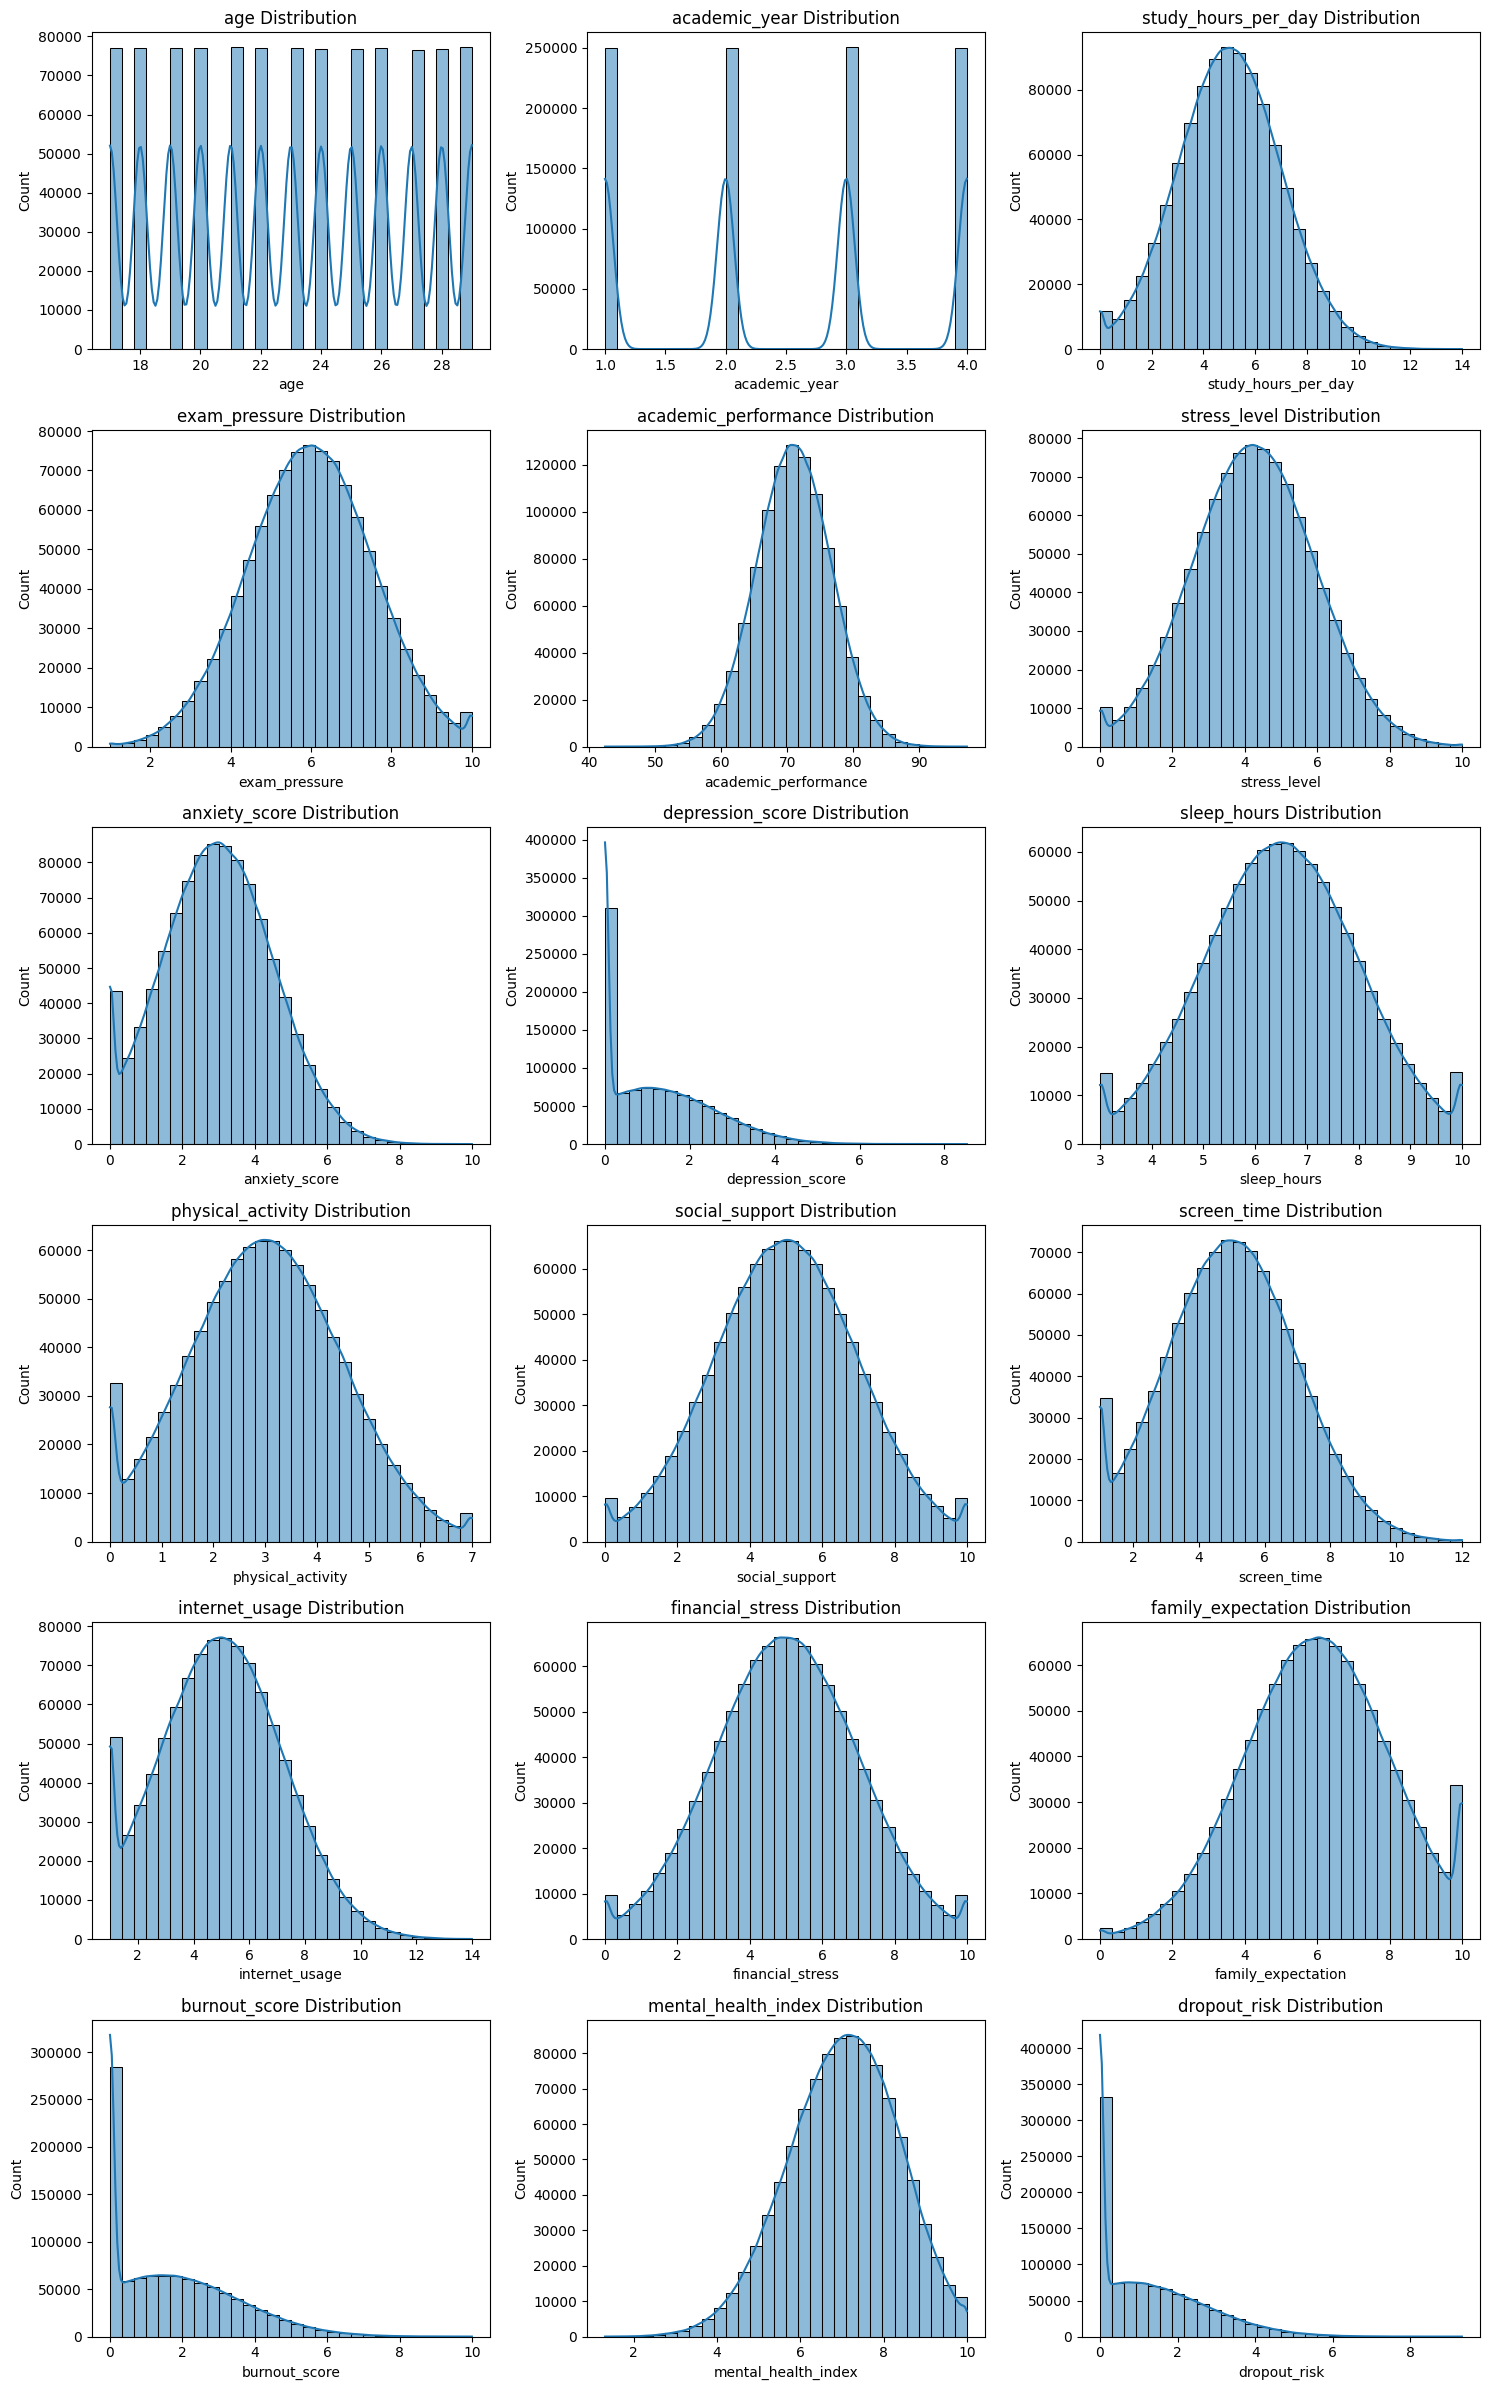

In [15]:
### EDA
### numerical features
n_cols = 3
n_rows = math.ceil(len(num_cols)/n_cols)
fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))

axes = axes.flatten()
for i,col in enumerate(num_cols):
    sns.histplot(x=df[col],bins=30,kde=True,ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
### remove empty plot
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

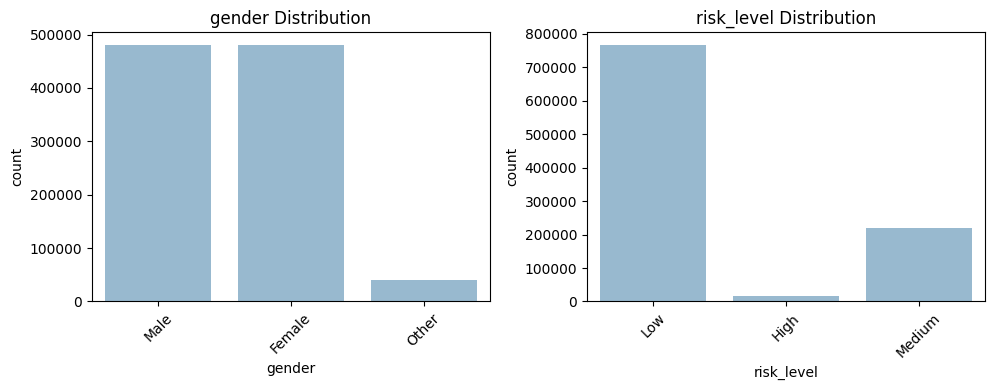

In [16]:
### EDA
### categorical features
n_cols = 3
n_rows = math.ceil(len(cat_cols)/n_cols)
fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))
axes = axes.flatten()
for i,col in enumerate(cat_cols):
    sns.countplot(x=df[col],ax=axes[i],alpha=0.5)
    axes[i].tick_params(axis="x",rotation=45)
    axes[i].set_title(f"{col} Distribution")

### remove empty plot
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

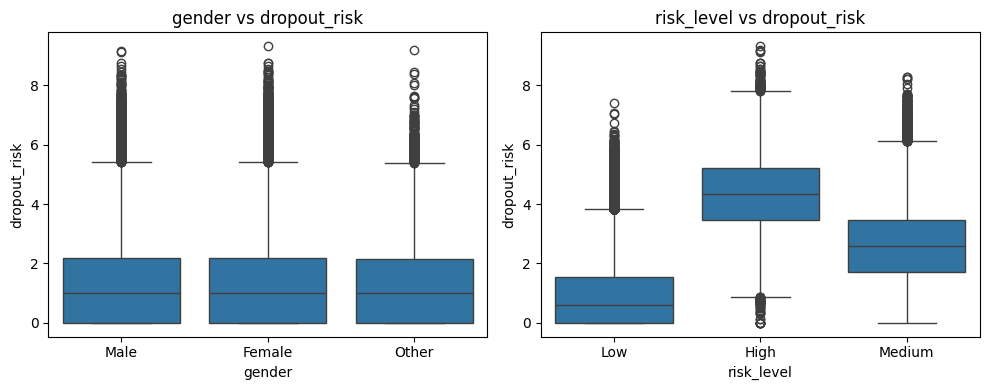

In [17]:
### Relationship analysis
n_cols = 2
n_rows = math.ceil(len(cat_cols)/n_cols)
fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))
axes = axes.flatten()
for i,col in enumerate(cat_cols):
    sns.boxplot(x=df[col],y=df["dropout_risk"],ax=axes[i])
    axes[i].set_title(f"{col} vs dropout_risk")
### remove empty plots
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

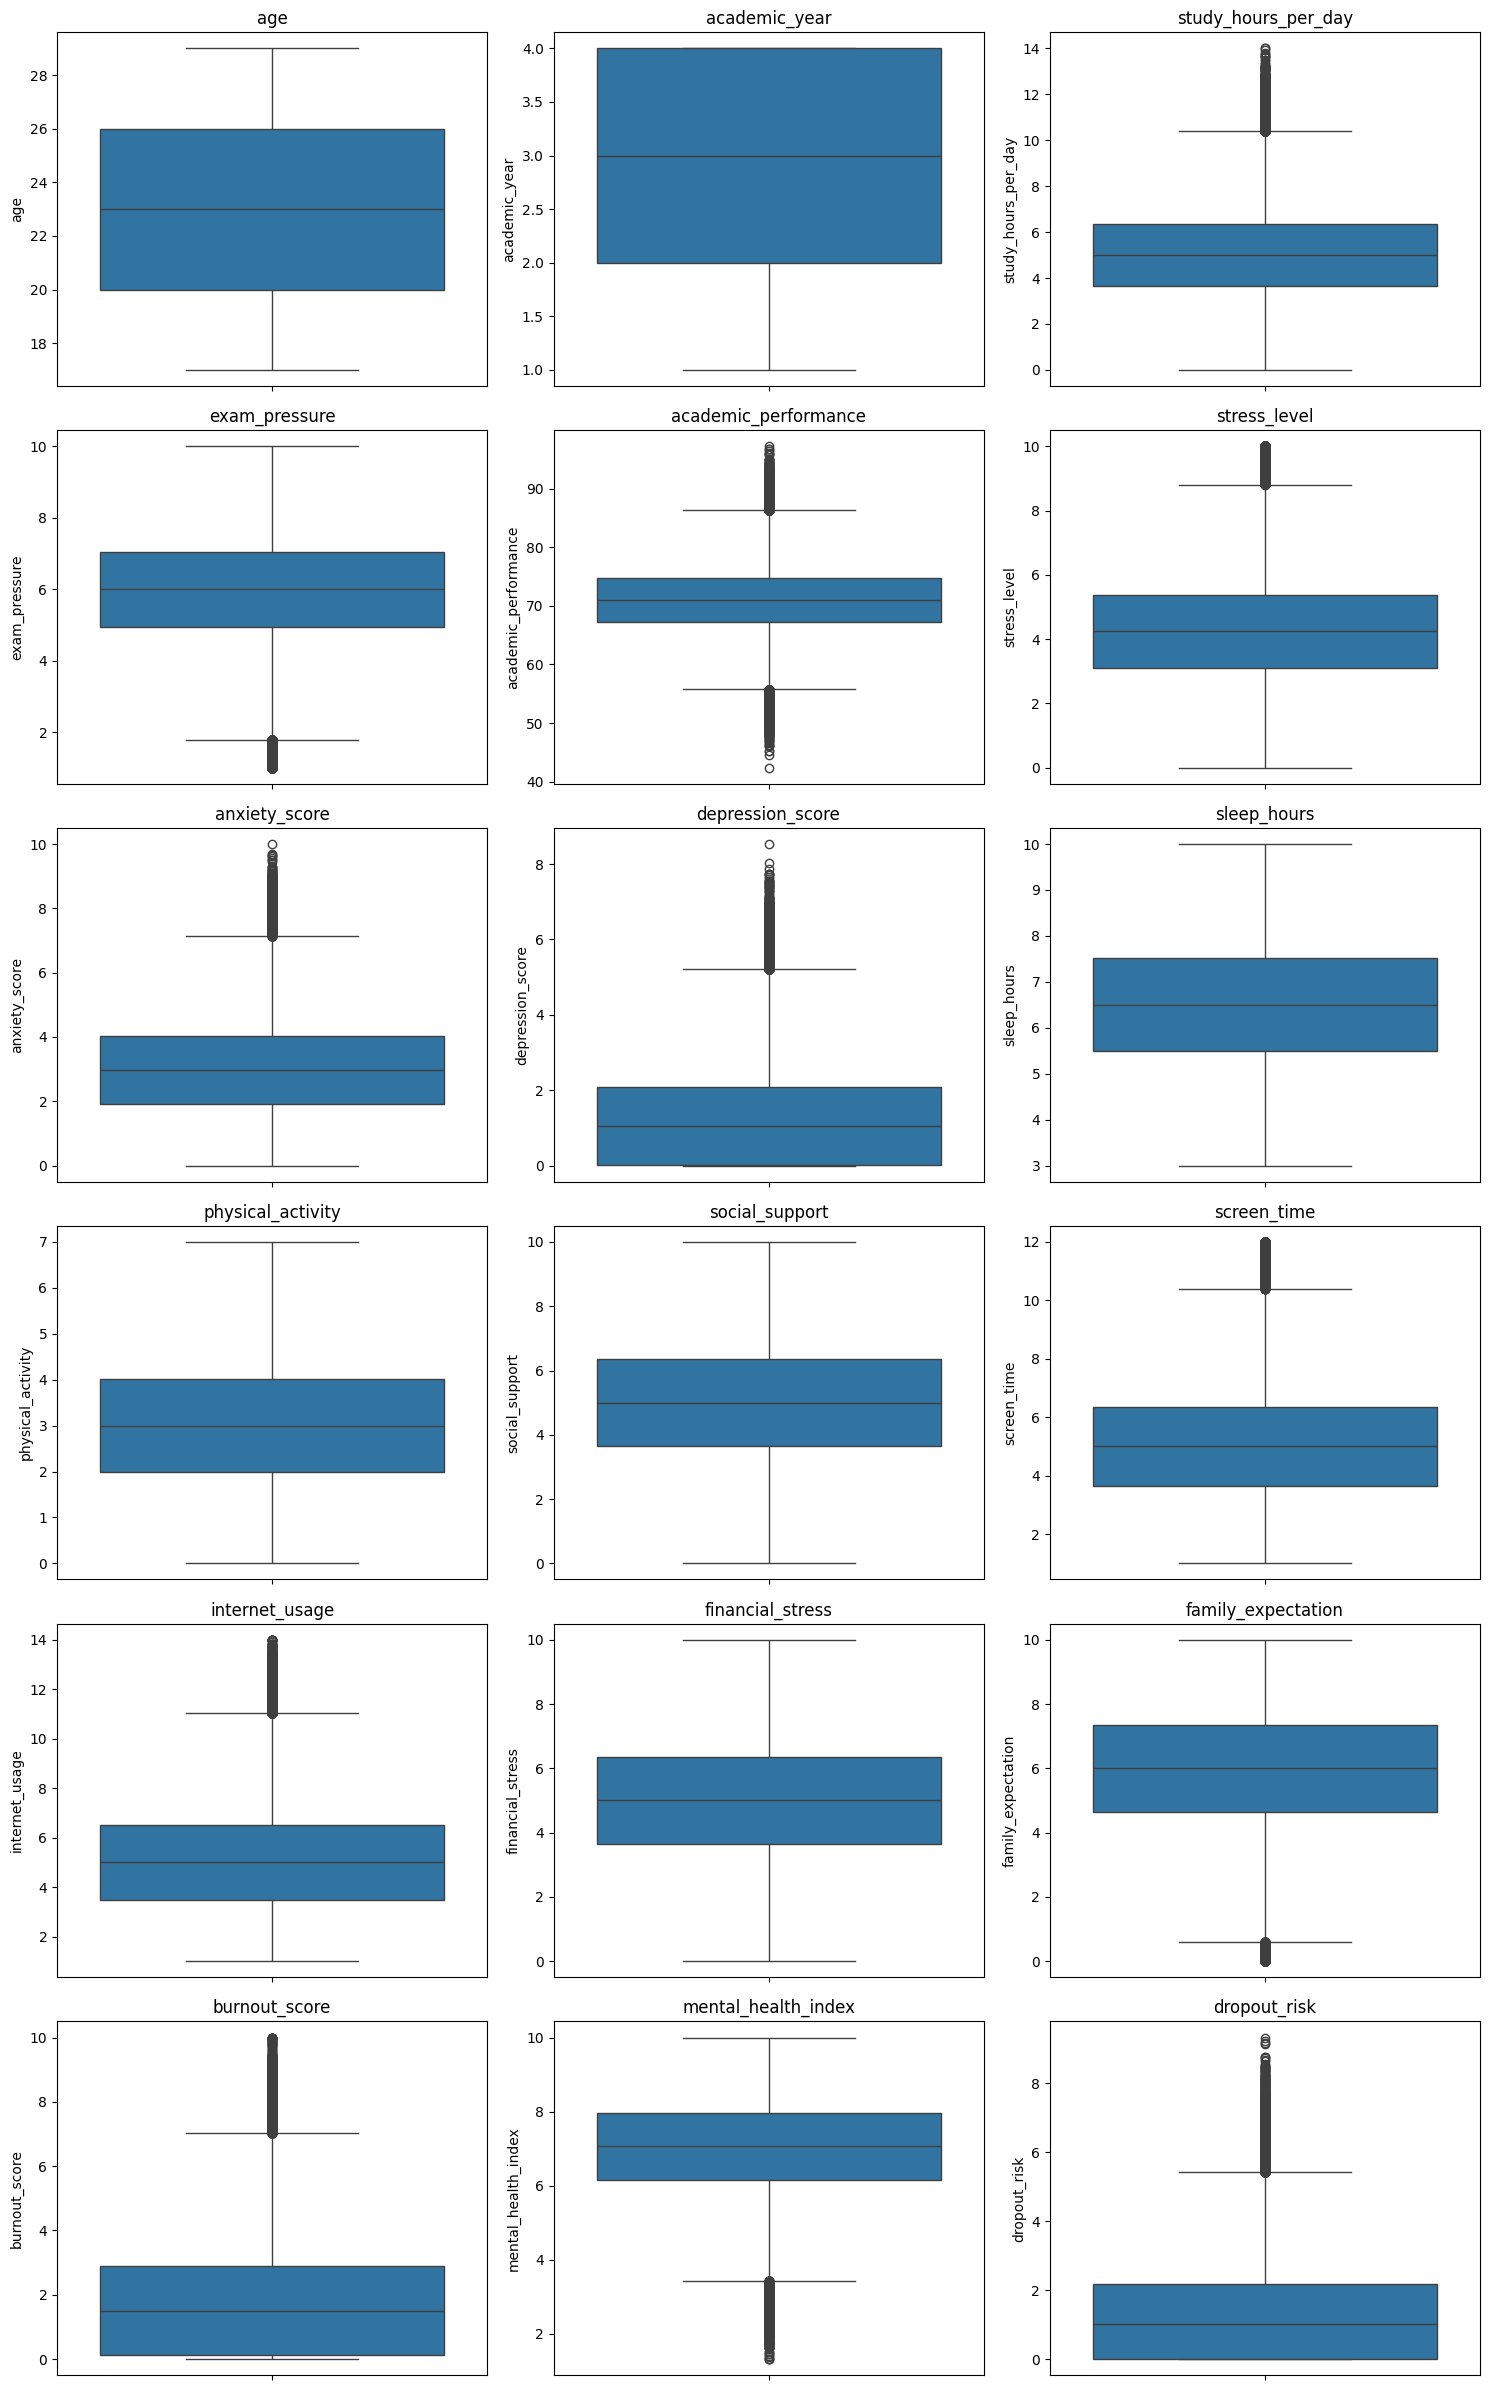

In [18]:
### outlier detection
n_cols = 3
n_rows = math.ceil(len(num_cols)/n_cols)
fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))
axes = axes.flatten()
for i,col in enumerate(num_cols):
    sns.boxplot(y=df[col],ax=axes[i])
    axes[i].set_title(col)
### remove empty plots
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

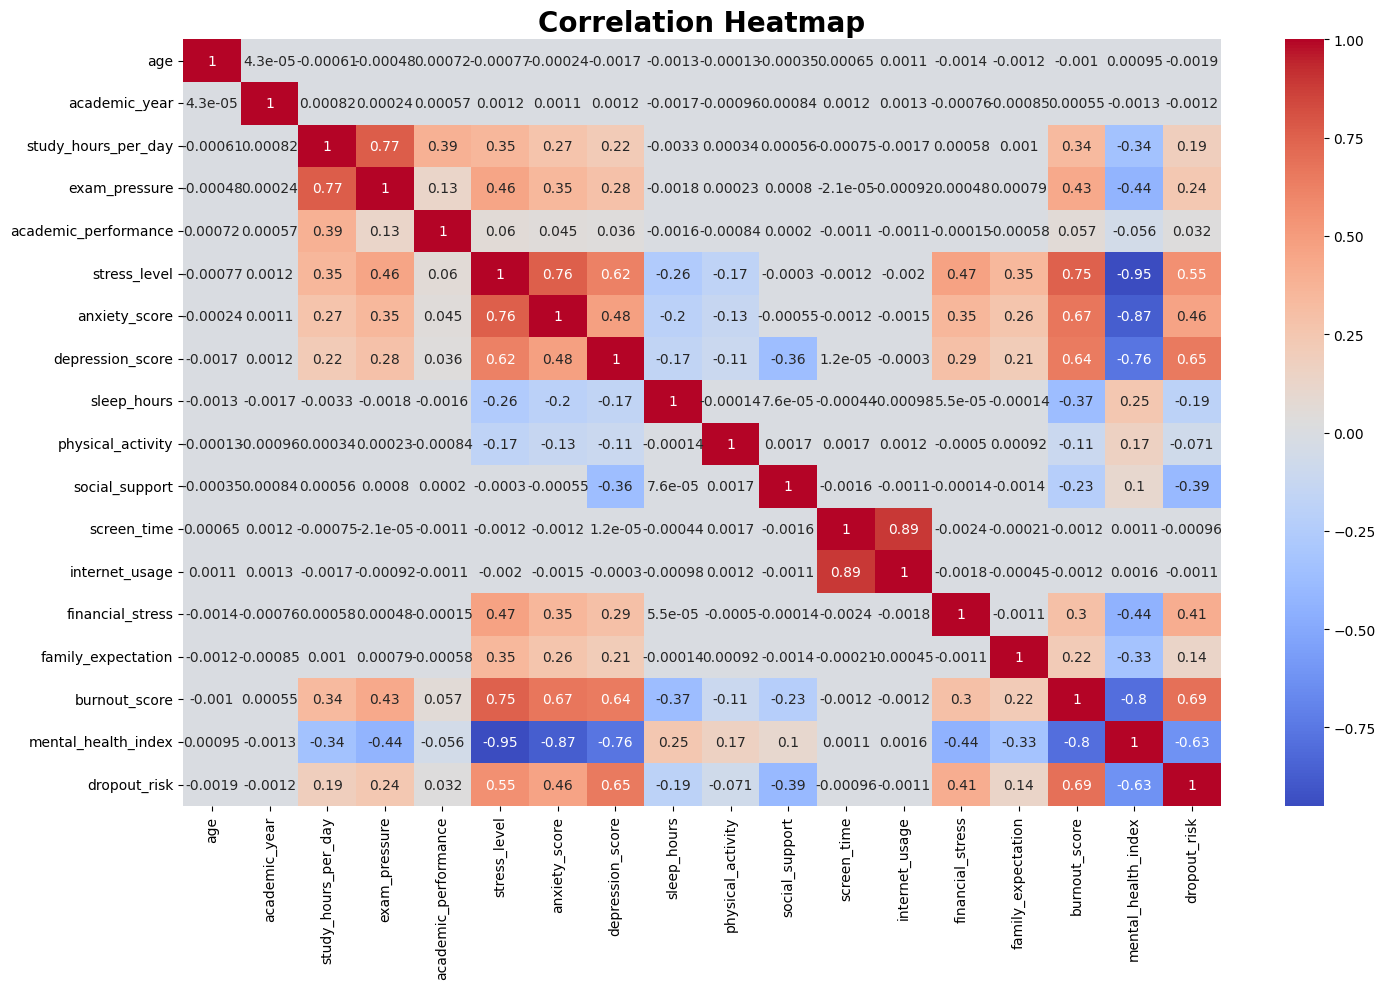

In [19]:
### correlation heatmap
corr_map = df[num_cols].corr()
### heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr_map,
            annot = True,
            cmap = "coolwarm")
plt.title("Correlation Heatmap",fontweight="bold",fontsize=20)
plt.tight_layout()
plt.show()

In [20]:
# Since the target is "risk_level", we keep "risk_level" as our target variable.
# We drop "dropout_risk" to avoid target leakage (since we want to predict risk_level based on other features).
df = df.drop("dropout_risk", axis=1, errors="ignore")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   age                   1000000 non-null  int64   
 1   gender                1000000 non-null  object  
 2   academic_year         1000000 non-null  int64   
 3   study_hours_per_day   1000000 non-null  float64 
 4   exam_pressure         1000000 non-null  float64 
 5   academic_performance  1000000 non-null  float64 
 6   stress_level          1000000 non-null  float64 
 7   anxiety_score         1000000 non-null  float64 
 8   depression_score      1000000 non-null  float64 
 9   sleep_hours           1000000 non-null  float64 
 10  physical_activity     1000000 non-null  float64 
 11  social_support        1000000 non-null  float64 
 12  screen_time           1000000 non-null  float64 
 13  internet_usage        1000000 non-null  float64 
 14  financial_stress   

In [22]:
### Logistic Regression

### seperate features
X = df.drop("risk_level", axis=1)
y = df["risk_level"]

### split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### nominal category
nominal_cat = ["gender"]
### numerical
num_cols = X_train.select_dtypes(include="number").columns

### transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cat),
        ("numerical", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight={
        "Low": 1,
        "Medium": 1.5,
        "High": 1
    },
    random_state=42,
    solver="lbfgs",
    max_iter=200,
)
### pipeline
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf_model", model)
    ]
)

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['risk_level']),
                                                 ('numerical', StandardScaler(),
                                                  Index(['age', 'academic_year', 'study_hours_per_day', 'exam_pressure',
       'acad...formance', 'stress_level', 'anxiety_score',
       'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'burnout_score', 'mental_health_index'],
      dtype='object'))])),
                ('clf_model',
                 LogisticRegression(class_weight={'High': 1, 'Low': 1,
                                                  'Medium': 1.5},
                                    max_iter=200, random_state=42))])

In [23]:
### model evaluation

y_pred = pipe.predict(X_test)

acc_scr = accuracy_score(y_test,y_pred)
pre_scr = precision_score(y_test,y_pred,average="weighted")
rec_scr = recall_score(y_test,y_pred,average="weighted")
f1_scr = f1_score(y_test,y_pred,average="weighted")
clf_rprt = classification_report(y_test,y_pred)
con_mat = confusion_matrix(y_test,y_pred)

print("Logistic Regression")
print(f"Accuracy score = {acc_scr}")
print(f"Precision score = {pre_scr}")
print(f"Recall score = {rec_scr}")
print(f"F1 score = {f1_scr}")
print(f"\n Classification Report \n {clf_rprt}")
print(f"\n Confusion matrix \n {con_mat}")

Logistic Regression
Accuracy score = 0.634305
Precision score = 0.6719158379362663
Recall score = 0.634305
F1 score = 0.6428797836143985

 Classification Report 
               precision    recall  f1-score   support

        High       0.80      0.64      0.71     66667
         Low       0.74      0.60      0.66     66666
      Medium       0.48      0.66      0.55     66667

    accuracy                           0.63    200000
   macro avg       0.67      0.63      0.64    200000
weighted avg       0.67      0.63      0.64    200000


 Confusion matrix 
 [[42831  1272 22564]
 [  965 39966 25735]
 [ 9817 12786 44064]]


In [24]:
### XGBClassifier

### encode target feature
le = LabelEncoder()
y_labelled = le.fit_transform(y)

### split
X_train, X_test, y_train_label, y_test_label = train_test_split(
    X, y_labelled, test_size=0.2, random_state=42, stratify=y_labelled
)

### nominal category
nominal_cat = ["gender"]
### numerical
num_cols = X_train.select_dtypes(include="number").columns

### transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cat),
        ("numerical", "passthrough", num_cols),
    ],
    remainder="passthrough"
)
### sample weight
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_label
)
### model
model = XGBClassifier(
            n_estimators=200,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=3,
            learning_rate=0.03,
            random_state=42,
            n_jobs=1
        )
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf_model", model)
    ]
)

pipe.fit(X_train,
         y_train_label,
         clf_model__sample_weight=sample_weights)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['risk_level']),
                                                 ('numerical', 'passthrough',
                                                  Index(['age', 'academic_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=1, num_class=3, ...))])

In [25]:
### model evaluation
y_pred_label = pipe.predict(X_test)

### decode
y_pred = le.inverse_transform(y_pred_label)
y_test = le.inverse_transform(y_test_label)

acc_scr = accuracy_score(y_test,y_pred)
pre_scr = precision_score(y_test,y_pred,average="weighted")
rec_scr = recall_score(y_test,y_pred,average="weighted")
f1_scr = f1_score(y_test,y_pred,average="weighted")
clf_rprt = classification_report(y_test,y_pred)
con_mat = confusion_matrix(y_test,y_pred)

print("XGB Classifier")
print(f"Accuracy score = {acc_scr}")
print(f"Precision score = {pre_scr}")
print(f"Recall score = {rec_scr}")
print(f"F1 score = {f1_scr}")
print(f"\n Classification Report \n {clf_rprt}")
print(f"\n Confusion matrix \n {con_mat}")

XGB Classifier
Accuracy score = 0.644055
Precision score = 0.6426272844049074
Recall score = 0.644055
F1 score = 0.6430945737992317

 Classification Report 
               precision    recall  f1-score   support

        High       0.74      0.73      0.74     66667
         Low       0.68      0.72      0.70     66666
      Medium       0.50      0.48      0.49     66667

    accuracy                           0.64    200000
   macro avg       0.64      0.64      0.64    200000
weighted avg       0.64      0.64      0.64    200000


 Confusion matrix 
 [[48408  2548 15711]
 [ 1857 48158 16651]
 [14782 19640 32245]]


In [28]:
### feature engieering

df["distress_score"] = (df["stress_level"]+df["burnout_score"]+df["depression_score"])/3
df["mental_wellness"] = df["mental_health_index"]-df["distress_score"]
df["stress_depression"] = df["stress_level"] * df["depression_score"]
df["lifestyle_score"] = df["sleep_hours"] * df["physical_activity"]
df["academic_score"] = df["study_hours_per_day"] * df["academic_performance"]
df["social_pressure"] = df["exam_pressure"] + df["anxiety_score"] + df["financial_stress"] + df["family_expectation"] - df["social_support"]
df["academic_social_ratio"] = df["academic_score"] / (df["social_pressure"]+1)
df["stress_anxiety"] = df["stress_level"] * df["anxiety_score"]
df["net_wellbeing"] = df["mental_health_index"]-df["stress_level"]-df["anxiety_score"]

In [29]:
df.columns

Index(['age', 'gender', 'academic_year', 'study_hours_per_day',
       'exam_pressure', 'academic_performance', 'stress_level',
       'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'burnout_score', 'mental_health_index',
       'risk_level', 'dropout_labels', 'distress_score', 'mental_wellness',
       'stress_depression', 'lifestyle_score', 'academic_score',
       'social_pressure', 'academic_social_ratio', 'stress_anxiety',
       'net_wellbeing'],
      dtype='object')

In [30]:
### XGB with engineered features

### seperate features
X = df.drop("risk_level", axis=1)
y = df["risk_level"]

### encode the target feature
le = LabelEncoder()
y_labelled = le.fit_transform(y)

### split
X_train, X_test, y_train_label, y_test_label = train_test_split(
    X, y_labelled, test_size=0.2, random_state=42, stratify=y_labelled
)

### nominal category
nominal_cat = ["gender"]
### numerical
num_cols = X_train.select_dtypes(include="number").columns

### transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cat),
        ("numerical", "passthrough", num_cols)
    ],
    remainder="passthrough"
)
### explicit class weight
class_weight = {
    0: 1, # high class
    1: 1, # low class
    2: 1.4 # Medium class
}

### sample weight
sample_weights = [class_weight[y] for y in y_train_label]
### XGBClassifier model
model = XGBClassifier(
            n_estimators=400,
            max_depth=7,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=3,
            learning_rate=0.03,
            random_state=42,
            n_jobs=1
        )

pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf_model", model)
    ]
)

pipe.fit(X_train,
         y_train_label,
         clf_model__sample_weight=sample_weights
         )

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['risk_level']),
                                                 ('numerical', 'passthrough',
                                                  Index(['age', 'academic_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=1, num_class=3, ...))])

In [31]:
### evaluation
y_pred_label = pipe.predict(X_test)

### decode
y_pred = le.inverse_transform(y_pred_label)
y_test = le.inverse_transform(y_test_label)

acc_scr = accuracy_score(y_test,y_pred)
pre_scr = precision_score(y_test,y_pred,average="weighted")
rec_scr = recall_score(y_test,y_pred,average="weighted")
f1_scr = f1_score(y_test,y_pred,average="weighted")
clf_rprt = classification_report(y_test,y_pred)
con_mat = confusion_matrix(y_test,y_pred)

print("XGB Classifier with engineered features")
print(f"Accuracy score = {acc_scr}")
print(f"Precision score = {pre_scr}")
print(f"Recall score = {rec_scr}")
print(f"F1 score = {f1_scr}")
print(f"\n Classification Report \n {clf_rprt}")
print(f"\n Confusion matrix \n {con_mat}")

XGB Classifier with engineered features
Accuracy score = 0.634315
Precision score = 0.6698130520568498
Recall score = 0.634315
F1 score = 0.6428053664845745

 Classification Report 
               precision    recall  f1-score   support

        High       0.80      0.64      0.71     66667
         Low       0.73      0.61      0.67     66666
      Medium       0.48      0.65      0.55     66667

    accuracy                           0.63    200000
   macro avg       0.67      0.63      0.64    200000
weighted avg       0.67      0.63      0.64    200000


 Confusion matrix 
 [[42796  1339 22532]
 [  973 40613 25080]
 [ 9909 13304 43454]]
